# 03 — SEC 10-K Text Stats EDA

Profiles `LADINGLENS_DB.RAW.SEC_10K_FILINGS` (19 of 25 target tickers loaded in Phase 2).

In [1]:

import os
import re
from pathlib import Path

import pandas as pd
import plotly.express as px
import snowflake.connector
from dotenv import load_dotenv
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent
load_dotenv(dotenv_path=REPO_ROOT / ".env")
FIG_DIR = REPO_ROOT / "docs" / "eda-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = snowflake.connector.connect(
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ.get("SNOWFLAKE_PASSWORD"),
    authenticator=os.environ.get("SNOWFLAKE_AUTHENTICATOR", "snowflake"),
    role=os.environ.get("SNOWFLAKE_ROLE"),
    warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE"),
    database=os.environ.get("SNOWFLAKE_DATABASE"),
    schema=os.environ.get("SNOWFLAKE_SCHEMA"),
)


def q(sql, params=None):
    cur = conn.cursor()
    try:
        cur.execute(sql, params)
        cols = [d[0].lower() for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    finally:
        cur.close()


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.write_image(str(path), width=1200, height=600, scale=2)
    print(f"Saved {path.relative_to(REPO_ROOT)}")
    # Display the static PNG (not fig.show()'s interactive JSON) so the chart
    # actually survives `jupyter nbconvert --to html` -- Plotly's interactive
    # mimetype isn't representable in a plain HTML export.
    display(Image(str(path)))


TABLE = "LADINGLENS_DB.RAW.SEC_10K_FILINGS"
print("Connected.")


Connected.


## a. Filings loaded — the 19 successes and the 6 known Phase 2 failures

In [2]:

filings = q(f'''
    SELECT ticker, filing_date, item_1a_length, item_7_length
    FROM {TABLE}
    ORDER BY ticker
''')
filings


,ticker,filing_date,item_1a_length,item_7_length
0,AAPL,2025-10-31,69611,0
1,AMD,2025-02-05,126677,0
2,ANET,2025-02-19,202296,51
3,CAT,2025-02-14,322929,77985
4,CSCO,2025-09-03,251233,0
5,DE,2025-12-18,109004,0
6,ETN,2025-02-27,260268,218
7,HPQ,2025-12-10,99082,51
8,LEVI,2025-01-29,138837,51
9,LULU,2025-03-27,295456,45943


In [3]:

FAILED_TICKERS = {
    "DELL": "Item 1A extraction <5000 chars (filer format quirk)",
    "INTC": "Item 1A extraction <5000 chars (filer format quirk)",
    "EMR": "Item 1A extraction <5000 chars (filer format quirk)",
    "JNPR": "ticker->CIK resolution failed (sec-edgar-downloader)",
    "HBI": "ticker->CIK resolution failed (sec-edgar-downloader)",
    "GES": "ticker->CIK resolution failed (sec-edgar-downloader)",
}
print(f"Loaded: {len(filings)}/25 target tickers")
print("Explicitly known failures from Phase 2:")
for t, reason in FAILED_TICKERS.items():
    print(f"  - {t}: {reason}")


Loaded: 19/25 target tickers
Explicitly known failures from Phase 2:
  - DELL: Item 1A extraction <5000 chars (filer format quirk)
  - INTC: Item 1A extraction <5000 chars (filer format quirk)
  - EMR: Item 1A extraction <5000 chars (filer format quirk)
  - JNPR: ticker->CIK resolution failed (sec-edgar-downloader)
  - HBI: ticker->CIK resolution failed (sec-edgar-downloader)
  - GES: ticker->CIK resolution failed (sec-edgar-downloader)


**Interpretation:** 19 of the 25 target tickers loaded successfully with a most-recent 10-K
(all filed in 2025). The 6 failures are carried forward unchanged from Phase 2 — 3 filer-specific
Item 1A extraction shortfalls and 3 ticker→CIK lookup failures in the `sec-edgar-downloader`
library. Not retried this phase, per plan; a later phase can revisit if these companies turn out
to matter for the chosen scope.

## b. Item 1A length distribution

Saved docs/eda-figures/nb03_item1a_length.png


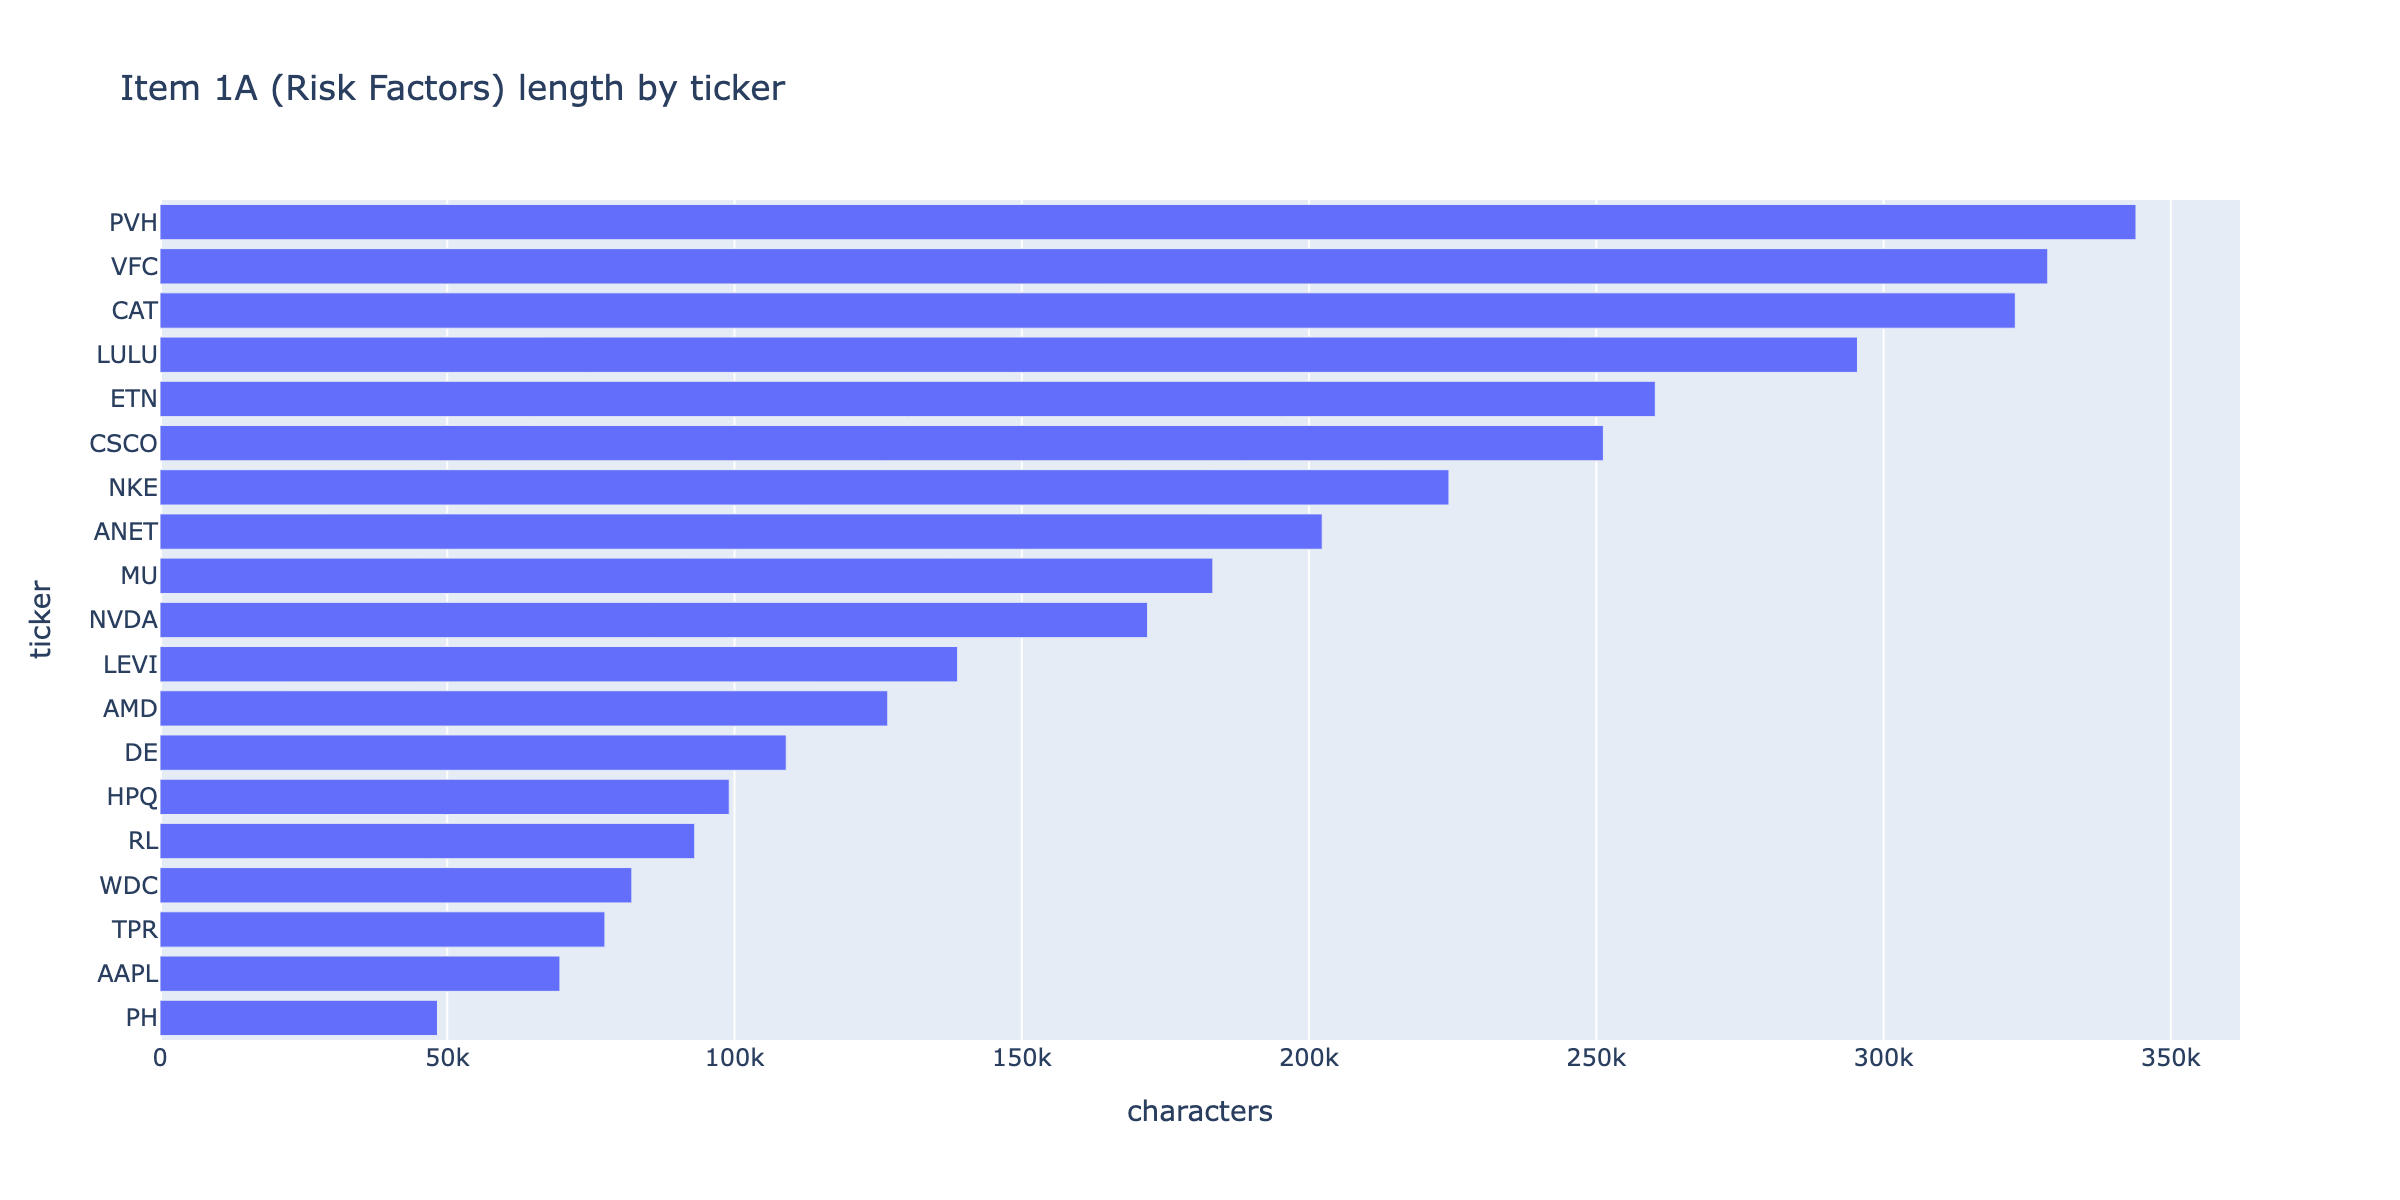

In [4]:

fig = px.bar(
    filings.sort_values('item_1a_length'), x='item_1a_length', y='ticker', orientation='h',
    title='Item 1A (Risk Factors) length by ticker',
    labels={'item_1a_length': 'characters'},
)
save_fig(fig, 'nb03_item1a_length')


In [5]:

rich = filings[filings['item_1a_length'] > 10000].sort_values('item_1a_length', ascending=False)
print(f"{len(rich)}/{len(filings)} tickers have >10k chars of Item 1A text (all of them, in this case)")
print("Richest 5:", list(rich.head(5)['ticker']))
print("Leanest 5:", list(filings.sort_values('item_1a_length').head(5)['ticker']))


19/19 tickers have >10k chars of Item 1A text (all of them, in this case)
Richest 5: ['PVH', 'VFC', 'CAT', 'LULU', 'ETN']
Leanest 5: ['PH', 'AAPL', 'TPR', 'WDC', 'RL']


**Interpretation:** every successfully-loaded filing clears 10k characters of Item 1A text
by a wide margin (tens of thousands of characters each) — the regex-boundary fix applied in
Phase 2 (picking the longest start/end span rather than the first Table-of-Contents match)
appears to generalize well across filers, not just the one it was originally debugged against.

## c. Item 7 (MD&A) usability assessment

In [6]:

usable_item7 = filings[filings['item_7_length'] > 3000]
print(f"{len(usable_item7)}/{len(filings)} tickers have usable Item 7 text (>3000 chars)")
print("Usable:", list(usable_item7['ticker']))
print("Not usable (<=3000 chars, likely broken extraction):")
filings[filings['item_7_length'] <= 3000][['ticker', 'item_7_length']]


6/19 tickers have usable Item 7 text (>3000 chars)
Usable: ['CAT', 'LULU', 'NKE', 'NVDA', 'PH', 'RL']
Not usable (<=3000 chars, likely broken extraction):


,ticker,item_7_length
0,AAPL,0
1,AMD,0
2,ANET,51
4,CSCO,0
5,DE,0
6,ETN,218
7,HPQ,51
8,LEVI,51
10,MU,0
14,PVH,0


**Verdict on Item 7:** confirms the Phase 2 finding — Item 7 (MD&A) extraction is
inconsistent across filers (several show 0 or single/double-digit lengths, meaning the
`ITEM 7A`/`ITEM 8` end-boundary regex is matching a Table-of-Contents occurrence rather than the
real section body for most filers, the same failure mode that was fixed for Item 1A but not
re-applied here). **Item 7 is marked deferred** for this phase, per the Phase 3 spec — it was not
a load-blocking criterion, and only Item 1A feeds the keyword-ranking and risk-passage extraction
below. A later phase should apply the same longest-span-across-all-matches fix used for Item 1A if
MD&A text becomes needed (e.g. for Cortex Search coverage in Phase 7).

## d. Supply-chain-risk keyword frequency in Item 1A

In [7]:

KEYWORDS = [
    "tariff", "Section 301", "Section 232", "China", "single supplier", "sole source",
    "concentration", "geopolitical", "supply chain disruption", "component shortage",
    "customs", "import duty",
]

texts = q(f"SELECT ticker, item_1a_text FROM {TABLE} WHERE item_1a_length >= 5000")


def count_keywords(text, keywords):
    text_low = (text or '').lower()
    return {kw: len(re.findall(re.escape(kw.lower()), text_low)) for kw in keywords}


rows = []
for _, r in texts.iterrows():
    counts = count_keywords(r['item_1a_text'], KEYWORDS)
    counts['ticker'] = r['ticker']
    counts['total_mentions'] = sum(counts[kw] for kw in KEYWORDS)
    rows.append(counts)

keyword_df = pd.DataFrame(rows).set_index('ticker').sort_values('total_mentions', ascending=False)
keyword_df


,tariff,Section 301,Section 232,China,single supplier,sole source,concentration,geopolitical,supply chain disruption,component shortage,customs,import duty,total_mentions
ticker,,,,,,,,,,,,,
ANET,47,0,0,48,0,2,4,8,6,1,2,0,118
LULU,12,0,0,41,0,0,3,8,2,0,2,0,68
PVH,3,0,0,30,0,0,1,0,5,0,0,0,39
LEVI,11,0,0,8,0,0,1,5,1,0,3,0,29
DE,16,0,0,5,0,0,0,3,2,0,2,0,28
HPQ,12,0,0,4,0,0,1,5,0,4,0,0,26
NKE,3,0,0,17,0,0,1,1,0,0,4,0,26
RL,16,0,0,3,0,0,0,1,2,0,4,0,26
WDC,16,0,0,1,1,0,2,3,0,0,1,0,24


Saved docs/eda-figures/nb03_keyword_ranking.png


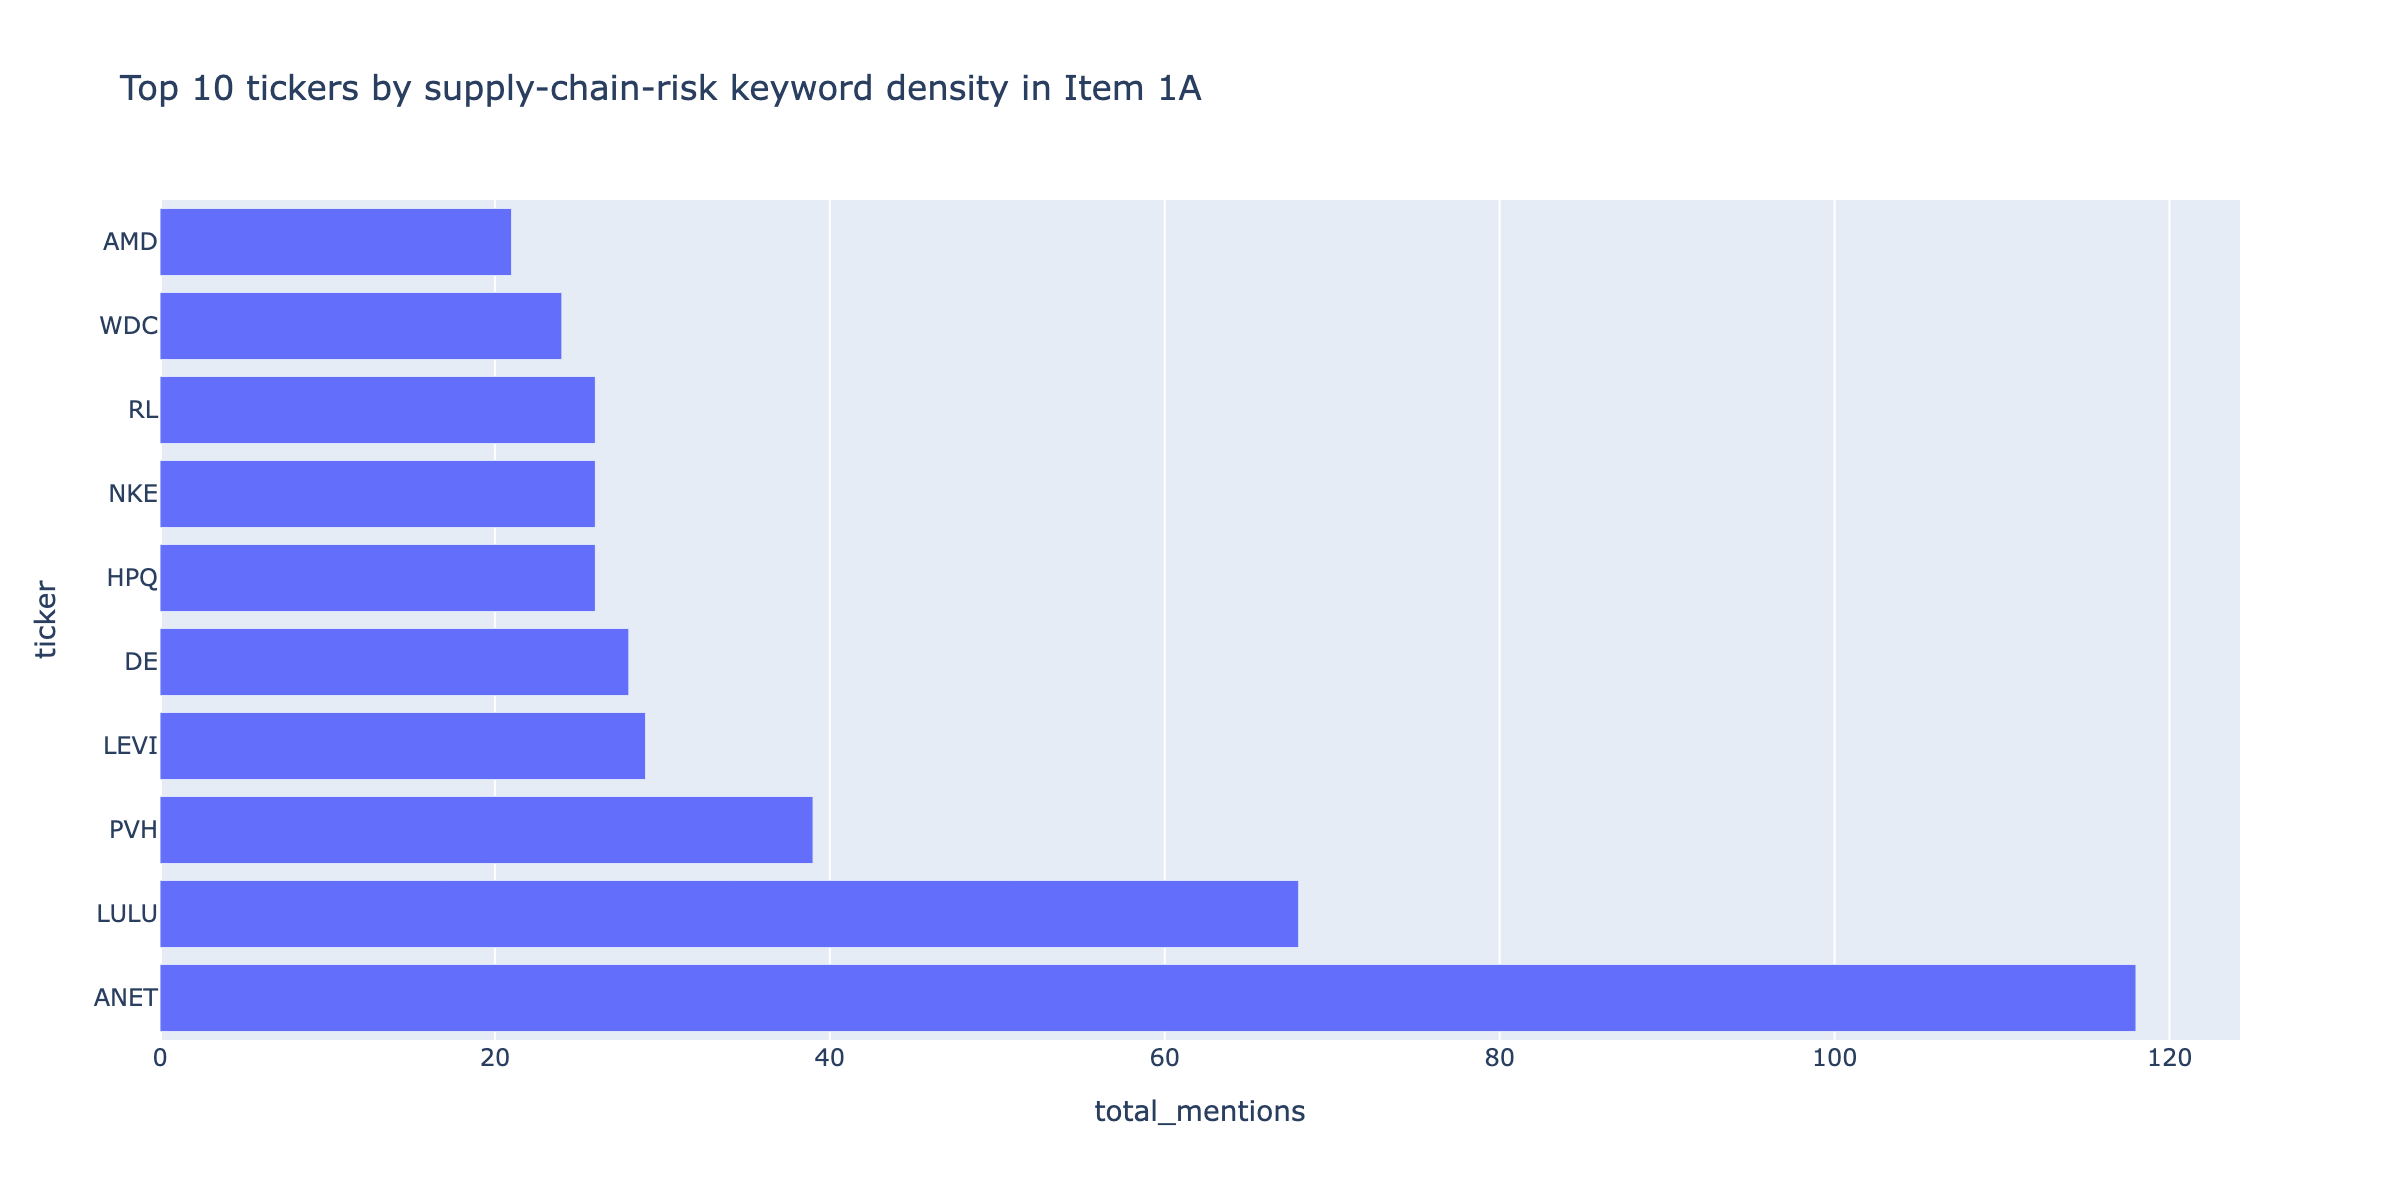

Spotlight companies (top 5-10 by supply-chain-risk mentions):
['ANET', 'LULU', 'PVH', 'LEVI', 'DE', 'HPQ', 'NKE', 'RL', 'WDC', 'AMD']


In [8]:

spotlight = keyword_df.head(10)
fig = px.bar(
    spotlight.reset_index(), x='total_mentions', y='ticker', orientation='h',
    title='Top 10 tickers by supply-chain-risk keyword density in Item 1A',
)
save_fig(fig, 'nb03_keyword_ranking')
print("Spotlight companies (top 5-10 by supply-chain-risk mentions):")
print(list(spotlight.head(10).index))


**Interpretation:** ranking by total keyword mentions across the 12 supply-chain/tariff
terms surfaces the filers whose Item 1A most substantively discusses tariff exposure, sourcing
concentration, and geopolitical/customs risk — as opposed to filers who mention "China" once in
passing. The top 5-10 here become the "spotlight companies" for the Phase 4-8 demo narrative,
cross-referenced against BoL linkage feasibility in notebook 04.

## e. Sample verbatim risk passages (supplier-concentration specific)

In [9]:

import html

CONCENTRATION_PATTERNS = [
    r'single[- ]?source', r'sole[- ]?source', r'single supplier', r'concentrat',
]
# 'concentrat' alone also matches unrelated pension/financial-instrument risk language
# (e.g. "no significant concentrations of risk within the plan assets") -- require a
# supply-chain-adjacent word nearby to keep only genuinely relevant matches.
SUPPLY_CHAIN_CONTEXT = re.compile(
    r'supplier|sourc|manufactur|component|raw material|vendor|factory|geographic|import|tariff',
    re.IGNORECASE,
)
EXCLUDE_CONTEXT = re.compile(r'pension|plan assets|money market|stockholder activism', re.IGNORECASE)


def find_passages(text, ticker, n_chars=600):
    if not text:
        return []
    passages = []
    for pat in CONCENTRATION_PATTERNS:
        for m in re.finditer(pat, text, re.IGNORECASE):
            start = max(0, m.start() - 200)
            end = min(len(text), m.start() + n_chars)
            snippet = html.unescape(text[start:end].strip())
            if EXCLUDE_CONTEXT.search(snippet):
                continue
            if pat == 'concentrat' and not SUPPLY_CHAIN_CONTEXT.search(snippet):
                continue
            passages.append(snippet)
    return passages


all_passages = []
for _, r in texts.iterrows():
    for snippet in find_passages(r['item_1a_text'], r['ticker'])[:3]:
        all_passages.append({'ticker': r['ticker'], 'snippet': snippet})

passages_df = pd.DataFrame(all_passages)
print(f"{len(passages_df)} candidate concentration-related passages found across {passages_df['ticker'].nunique()} tickers "
      f"(after excluding pension/financial-instrument false positives from the bare 'concentrat' pattern)")
passages_df.head(10)


24 candidate concentration-related passages found across 12 tickers (after excluding pension/financial-instrument false positives from the bare 'concentrat' pattern)


,ticker,snippet
0,DE,e to adversely affect our ability to meet comm...
1,CAT,for credit losses is generally not recorded up...
2,CAT,ceivables primarily represent receivables unde...
3,LEVI,onged manufacturing or transportation disrupti...
4,VFC,k units and restricted stock. In periods of a ...
5,VFC,s and has established internal policies regard...
6,ANET,", connectors, optics, cables, custom-tooled sh..."
7,ANET,solvency or credit difficulties confronting ou...
8,ANET,022. This variability in customer concentratio...
9,CSCO,recorded to a separate component of AOCI. Inco...


In [10]:

# Pick 5 diverse, substantive passages (dedup near-identical snippets per ticker, prefer spotlight tickers).
chosen = []
seen_tickers = set()
spotlight_tickers = list(spotlight.head(10).index)
for t in spotlight_tickers:
    candidates = passages_df[passages_df['ticker'] == t]
    if len(candidates) and t not in seen_tickers:
        chosen.append(candidates.iloc[0])
        seen_tickers.add(t)
    if len(chosen) >= 5:
        break
# Backfill from any remaining tickers if spotlight didn't yield 5 clean passages.
if len(chosen) < 5:
    for t in passages_df['ticker'].unique():
        if t in seen_tickers:
            continue
        chosen.append(passages_df[passages_df['ticker'] == t].iloc[0])
        seen_tickers.add(t)
        if len(chosen) >= 5:
            break

filing_dates = filings.set_index('ticker')['filing_date'].to_dict()

lines = ["# Sample 10-K Risk-Factor Passages — Supplier Concentration\n",
         "Verbatim excerpts from Item 1A (Risk Factors), selected for explicit supplier/geographic",
         "concentration language. Saved as Cortex Search demo material for Phase 7.\n"]
for row in chosen:
    lines.append(f"## {row['ticker']} (filed {filing_dates.get(row['ticker'])})\n")
    lines.append(f"> {row['snippet'].strip()}\n")

output_path = REPO_ROOT / 'docs' / 'sample-risk-passages.md'
output_path.write_text('\n'.join(lines))
print(f"Wrote {len(chosen)} passages to {output_path.relative_to(REPO_ROOT)}: {[c['ticker'] for c in chosen]}")


Wrote 5 passages to docs/sample-risk-passages.md: ['ANET', 'LULU', 'LEVI', 'DE', 'HPQ']


**Interpretation:** these excerpts are saved verbatim (with ticker + filing-date
attribution) to `docs/sample-risk-passages.md` for later use as Cortex Search demo material —
the goal is passages that make the "structured shipment data + unstructured risk disclosure"
fusion story concrete and citable, not paraphrased.